In [1]:
import random
import numpy as np 
import matplotlib.pyplot as plt
import csv
import os
import sys
from scipy import stats

In [2]:
#bounds of x and y
BOUNDS_X = [0, 4]
BOUNDS_Y = [1, 6]

In [3]:
#fitness function
def fitness(position):
    x, y = position
    fitness_value = np.exp(-(x - 1)**2) + np.exp(-(y - 2)**2)
    
    return fitness_value

In [4]:
#repair location
def repair_position(pos):
    x, y = pos
    x = np.clip(x, BOUNDS_X[0], BOUNDS_X[1])
    y = np.clip(y, BOUNDS_Y[0], BOUNDS_Y[1])
    #enforce linear constraint: x + y <= 4
    if x + y > 4:
        #reduce y first, then x if needed
        y = max(BOUNDS_Y[0], 4 - x)
        if x + y > 4:
            x = 4 - y
    return np.array([x, y], dtype=float)

In [5]:
class Particle:
    def __init__(self, fitness_func, v_max):
        # init x and y random from the bounds
        x = np.random.uniform(BOUNDS_X[0], BOUNDS_X[1])
        y = np.random.uniform(BOUNDS_Y[0], BOUNDS_Y[1])
        #repair position
        self.position = repair_position(np.array([x, y]))
        self.velocity = np.random.uniform(-1, 1, size=2)
        self.fitness_func = fitness_func
        #add velocity limits per-dimension
        self.v_max = v_max
        self.p_best = self.position.copy()
        self.p_best_fitness = self.evaluate()

    def evaluate(self):
        return self.fitness_func(self.position)

    def update(self, g_best, w, c1, c2):
        r1 = np.random.random(2)
        r2 = np.random.random(2)
        #velocity updates v(t+1) = w*v(t) + c1*r1*(pBest - x) + c2*r2*(gBest - x)
        cognitive = c1 * r1 * (self.p_best - self.position)
        social = c2 * r2 * (g_best - self.position)
        self.velocity = w * self.velocity + cognitive + social

        #velocity clamping (per-dimension)
        for i in range(len(self.velocity)):
            self.velocity[i] = np.clip(self.velocity[i], -self.v_max[i], self.v_max[i])
        
        #position update
        self.position = self.position + self.velocity

        #repair position
        self.position = repair_position(self.position)

        #update personal best
        current_fitness = self.evaluate()
        if current_fitness > self.p_best_fitness:
            self.p_best = self.position.copy()
            self.p_best_fitness = current_fitness

In [6]:
class Swarm:
    def __init__(self, num_particles, fitness_func, w_max=0.9, w_min=0.4,
                 c1=2.0, c2=2.0, m_v=None):
        self.fitness_func = fitness_func
        #swarm size
        self.num_particles = num_particles
        #inertia weight upper bounds
        self.w_max = w_max
        #inertia weight lower bounds
        self.w_min = w_min
        #cognitive (self-confidence) acceleration constant
        self.c1 = c1
        #social (swarm-confidence) acceleration constant
        self.c2 = c2

        #velocity limit multiplier per dimension v_max = m_v * x_range for each dimension
        if m_v is None: m_v = [0.5, 0.5]
        x_range = BOUNDS_X[1] - BOUNDS_X[0] #4
        y_range = BOUNDS_Y[1] - BOUNDS_Y[0] #5
        self.v_max = np.array([m_v[0] * x_range, m_v[1] * y_range])

        self.particles = [Particle(self.fitness_func, self.v_max) for _ in range(num_particles)]
        self.g_best, self.g_best_fitness = self._find_global_best()

    def _find_global_best(self):
        best = max(self.particles, key=lambda p: p.p_best_fitness)
        return best.p_best.copy(), best.p_best_fitness

    def _get_inertia_weight(self, t, max_iter):
        #decreasing inertia weight: w(t) = w_max - t/T * (w_max - w_min)
        return self.w_max - (t / max_iter) * (self.w_max - self.w_min)

    def simulate(self, max_iter=200):
        history = [] #best-so-far at each iteration

        for t in range(1, max_iter + 1):
            w = self._get_inertia_weight(t, max_iter)

            for particle in self.particles:
                particle.update(self.g_best, w, self.c1, self.c2)
            
            #update global best
            new_g_best, new_g_best_fitness = self._find_global_best()
            if new_g_best_fitness > self.g_best_fitness:
                self.g_best = new_g_best
                self.g_best_fitness = new_g_best_fitness

            history.append(self.g_best_fitness)
            
        return self.g_best.copy(), self.g_best_fitness, history

# GA

In [7]:
class GeneticAlgorithm:

    def __init__(self, fitness_func, pop_size=50, crossover_rate=0.9, mutation_rate=0.1, max_iter=200):
        self.pop_size = pop_size
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.max_iter = max_iter
        self.genome_length = 13
        self.min_val = 0
        self.max_val = 10
        
        self.population = self._init_population()
        self.population_fitness = self._evaluate_fitness(self.population)
        
    def _decimal_to_binary(self, value):
        integer = round((value - self.min_val) / (self.max_val - self.min_val) * (2**self.genome_length - 1))
        binary = bin(max(0, integer))[2:]
        return binary.zfill(self.genome_length)

    def _binary_to_decimal(self, bits):
        binary_str = ''.join(str(bit) for bit in bits)
        integer = int(binary_str, 2)
        return round(self.min_val + integer * (self.max_val - self.min_val) / (2**self.genome_length - 1), 6)

    def _init_population(self):
        population = []
        for _ in range(self.pop_size):
            x = round(random.uniform(self.min_val, self.max_val), 3)
            y = round(random.uniform(self.min_val, self.max_val), 3)
            x_bits = [int(bit) for bit in self._decimal_to_binary(x)]
            y_bits = [int(bit) for bit in self._decimal_to_binary(y)]
            population.append({'x_bits': x_bits, 'x_decimal': x, 'y_bits': y_bits, 'y_decimal': y})
        return population

    def _evaluate_fitness(self, population):
        pop_with_fit = []
        for chrom in population:
            #get the x decimal and y decimal
            x, y = chrom['x_decimal'], chrom['y_decimal']

            # check if x and y fulfill the constraint, then the status will be True. If not, the status will be False. 
            status = (0 <= x <= 4) and (1 <= y <= 6) and (x + y <= 4)

            fitness_value = np.exp(-(x - 1)**2) + np.exp(-(y - 2)**2)
            if not status:
                if not (0 <= x <= 4):
                    R = -4
                    fitness_value += R * (abs((x + y) - 4)**2)
                if not (1 <= y <= 6):
                    R = -5
                    fitness_value += R * (abs((x + y) - 4)**2)
                if not (x + y <= 4):
                    R = -6
                    fitness_value += R * (abs((x + y) - 4)**2)

            pop_with_fit.append({**chrom, 'fitness': fitness_value, 'status_constraint': status})
        return pop_with_fit

    def _check_status_population(self, population_fitness):
        #if the suitable chromosome inside population empty or only 1, then return False because it's not ideal
        count_keep = sum(1 for c in population_fitness if c['status_constraint'])
        if count_keep <= 1:
            return False
        
        return population_fitness

    def _roulette_wheel_selection(self, population, prev_index):
        fitness_values = [c['fitness'] for c in population]

        #shifting fitness value so the minimum is 0
        min_fit = min(fitness_values)
        epsilon = 1e-6
        shifted = [f - min_fit + epsilon for f in fitness_values]

        #make the probability of each chromosome
        total = sum(shifted)
        probs = [f / total for f in shifted]

        #select index by the probability
        selected_index = np.random.choice(len(population), p=probs)
        attempts = 0

        #check if the selected index is same as the another party. make sure it's different!
        while selected_index == prev_index and attempts < 10:
            #if it's same, do random selection index again
            selected_index = np.random.choice(len(population), p=probs)
            attempts += 1
        return selected_index, population[selected_index]

    def _crossover(self, p1, p2):
        # random value to know should we do the crossover or not, as long as not exceeds the crossover rate
        if random.random() > self.crossover_rate:
            return p1['x_bits'], p2['x_bits'], p1['y_bits'], p2['y_bits']
        def is_valid(x1, x2, y1, y2):
            #checking the constraint
            return (0 <= x1 <= 4 and 0 <= x2 <= 4 and
                    1 <= y1 <= 6 and 1 <= y2 <= 6 and
                    x1 + y1 <= 4 and x2 + y2 <= 4)
        for _ in range(10):
            point = random.randint(1, self.genome_length - 1)

            #two-point crossover
            cx1 = np.concatenate([p1['x_bits'][:point], p2['x_bits'][point:]])
            cx2 = np.concatenate([p2['x_bits'][:point], p1['x_bits'][point:]])
            cy1 = np.concatenate([p1['y_bits'][:point], p2['y_bits'][point:]])
            cy2 = np.concatenate([p2['y_bits'][:point], p1['y_bits'][point:]])
            
            #convert to decimal
            x1, x2 = self._binary_to_decimal(cx1), self._binary_to_decimal(cx2)
            y1, y2 = self._binary_to_decimal(cy1), self._binary_to_decimal(cy2)
            
            if is_valid(x1, x2, y1, y2):
                #if valid, then return the offspring
                return cx1, cx2, cy1, cy2
        
        #if not, the parents will return so they won't have kids
        return p1['x_bits'], p2['x_bits'], p1['y_bits'], p2['y_bits']

    def _mutate(self, individual, constraint):
        mutated = individual.copy()

        #iterating until last genome
        for i in range(self.genome_length):
            #finding the random value. If it's fulfill the mutation rate, the mutation will be happened
            if random.random() < self.mutation_rate:
                mutated[i] = 1 - mutated[i]
        
        #change from binary to decimal
        decimal_val = self._binary_to_decimal(mutated)

        #check the constraints
        if constraint == 'x' and 0 <= decimal_val <= 4:
            return mutated
        elif constraint == 'y' and 1 <= decimal_val <= 6:
            return mutated
        
        #return to the original individual because doesn't fulfill the constraints
        return individual

    def simulate(self, max_iter=None):
        if max_iter is None: max_iter = self.max_iter
        generations = max_iter
        i = 0
        fitness_all = []
        x_all = []
        y_all = []
        status_all = []
        best_fitness_so_far = -np.inf

        while i < generations:
            result_check = self._check_status_population(self.population_fitness)
            if result_check is False:
                self.population = self._init_population()
                self.population_fitness = self._evaluate_fitness(self.population)
                generations += 1

                #carry forward previous best if exists
                if len(fitness_all) > 0:
                    fitness_all.append(fitness_all[-1])
                    x_all.append(x_all[-1])
                    y_all.append(y_all[-1])
                    status_all.append(status_all[-1])
                i += 1
                continue

            new_population = []
            ix = -1
            ix, p1 = self._roulette_wheel_selection(result_check, ix)
            ix, p2 = self._roulette_wheel_selection(result_check, ix)

            while len(new_population) < self.pop_size // 2:
                #crossover
                off_x1, off_x2, off_y1, off_y2 = self._crossover(p1, p2)

                #mutation
                mut_x1 = self._mutate(off_x1, 'x')
                mut_x2 = self._mutate(off_x2, 'x')
                mut_y1 = self._mutate(off_y1, 'y')
                mut_y2 = self._mutate(off_y2, 'y')

                dec_x1 = self._binary_to_decimal(mut_x1)
                dec_x2 = self._binary_to_decimal(mut_x2)
                dec_y1 = self._binary_to_decimal(mut_y1)
                dec_y2 = self._binary_to_decimal(mut_y2)

                child1 = dict(x_bits=mut_x1, x_decimal=dec_x1, y_bits=mut_y1, y_decimal=dec_y1)
                child2 = dict(x_bits=mut_x2, x_decimal=dec_x2, y_bits=mut_y2, y_decimal=dec_y2)

                temp_pop = [child1, child2]
                temp_fit = self._evaluate_fitness(temp_pop)
                #check again the population of the new children
                res_new = self._check_status_population(temp_fit)

                if res_new:
                    new_population.append(child1)
                    new_population.append(child2)
                    new_pop_fit = self._evaluate_fitness(new_population)
                    #check the population
                    res_full = self._check_status_population(new_pop_fit)
                    if res_full:
                        iy = -1
                        iy, p1 = self._roulette_wheel_selection(res_full, iy)
                        iy, p2 = self._roulette_wheel_selection(res_full, iy)
                else:
                    continue

            self.population_fitness = self._evaluate_fitness(new_population)
            best_chrom = max(self.population_fitness, key=lambda x: x['fitness'])
            current_best_fitness = best_chrom['fitness']

            #convergence logic
            if current_best_fitness >= best_fitness_so_far:
                best_fitness_so_far = current_best_fitness
                fitness_all.append(current_best_fitness)
                x_all.append(best_chrom['x_decimal'])
                y_all.append(best_chrom['y_decimal'])
                status_all.append(best_chrom['status_constraint'])
            else:
                fitness_all.append(fitness_all[-1])
                x_all.append(x_all[-1])
                y_all.append(y_all[-1])
                status_all.append(status_all[-1])
            i += 1

        best_idx = np.argmax(fitness_all)
        best_pos = np.array([x_all[best_idx], y_all[best_idx]])
        return best_pos, fitness_all[best_idx], fitness_all

In [8]:
def run_multiple(algo_class, num_runs=30, max_iter=200, **kwargs):
    all_fitness = []
    all_histories = []
    all_positions = []
    for _ in range(num_runs):
        if algo_class == 'pso':
            alg = Swarm(fitness_func=fitness, **kwargs)
        else:
            alg = GeneticAlgorithm(fitness_func=fitness, **kwargs)
        pos, fit, hist = alg.simulate(max_iter=max_iter)
        all_fitness.append(fit)
        all_histories.append(hist)
        all_positions.append(pos)
    return all_fitness, all_histories, all_positions


In [9]:
def plot_convergence(history, filename='pso_convergence.png', title='PSO Convergence Curve', 
                     csv_filename='pso_convergence_data.csv'):

    import matplotlib.pyplot as plt
    from matplotlib.ticker import FormatStrFormatter
    import csv
    
    iterations = list(range(1, len(history) + 1))
    fitness_values = history  # Already best-so-far from Swarm.simulate()

    with open(csv_filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Iteration', 'Global_Best_Fitness'])  # Header
        for i, fit in zip(iterations, fitness_values):
            writer.writerow([i, f'{fit:.9f}'])  # 9 decimal places for precision
    print(f"Convergence data saved to {csv_filename}")

    plt.figure(figsize=(10, 6))
    plt.plot(iterations, fitness_values, 'b-', linewidth=2, label='Global Best Fitness')
    
    # Labels and title
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Global Best Fitness', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.9f'))
    
    y_min, y_max = min(fitness_values), max(fitness_values)
    padding = (y_max - y_min) * 0.1 if y_max > y_min else 0.01
    plt.ylim(y_min - padding, y_max + padding)

    plt.axhline(y=fitness_values[-1], color='r', linestyle='--', alpha=0.5,
                label=f'Final: {fitness_values[-1]:.9f}')
    
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Convergence plot saved to {filename}")

In [10]:
NUM_RUNS = 30
MAX_ITER = 100
SWARM_SIZE = 50

In [11]:
np.random.seed(42)
random.seed(42)

# Running PSO single run

Running PSO
Convergence data saved to pso_convergence_data.csv


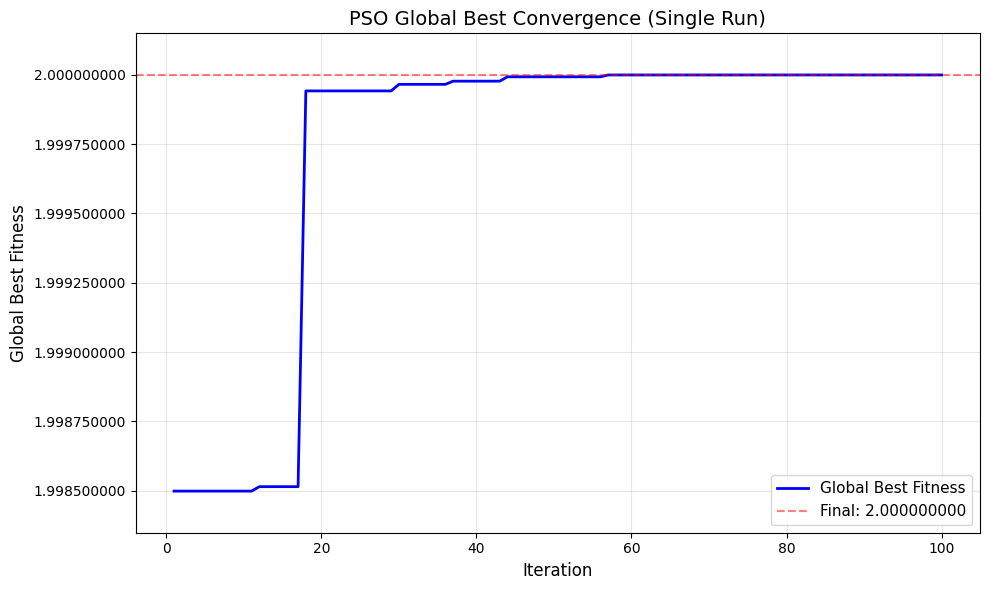

Convergence plot saved to pso_main_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000


In [12]:
print("Running PSO")

swarm = Swarm(num_particles=50, fitness_func=fitness, 
              w_max=0.9, w_min=0.4, c1=2.0, c2=2.0, m_v=[0.5, 0.5])

#get results of best position, best fitness, and history
best_pos, best_fit, history = swarm.simulate(max_iter=100)

#plot convergence
plot_convergence(history, filename='pso_main_convergence.png', 
                 title='PSO Global Best Convergence (Single Run)')

print(f"\nFinal Best Position: x={best_pos[0]:.4f}, y={best_pos[1]:.4f}")
print(f"Final Best Fitness: {best_fit:.6f}")

# Running 30 run

In [13]:
print("Running PSO (30 runs)")

pso_fitness, pso_histories, pso_positions = run_multiple(
    'pso', num_runs=NUM_RUNS, max_iter=MAX_ITER,
    num_particles=SWARM_SIZE, w_max=0.9, w_min=0.4,
    c1=2.0, c2=2.0, m_v=[0.5, 0.5]
)
print(f"PSO Mean fitness: {np.mean(pso_fitness):.6f} +/- {np.std(pso_fitness):.6f}")
print(f"PSO Best fitness: {np.max(pso_fitness):.6f}")


Running PSO (30 runs)
PSO Mean fitness: 2.000000 +/- 0.000000
PSO Best fitness: 2.000000


In [14]:
print("Running GA (30 runs)")

ga_fitness, ga_histories, ga_positions = run_multiple(
    'ga', num_runs=NUM_RUNS, max_iter=MAX_ITER,
    pop_size=SWARM_SIZE, crossover_rate=0.9, mutation_rate=0.1
)
print(f"GA Mean fitness: {np.mean(ga_fitness):.6f} +/- {np.std(ga_fitness):.6f}")
print(f"GA Best fitness: {np.max(ga_fitness):.6f}")


Running GA (30 runs)
GA Mean fitness: 1.999858 +/- 0.000201
GA Best fitness: 1.999993


# Parameter Single Run

Parameter Sensitivity single run: Inertia Weight
Convergence data saved to pso_w_max=0.9, w_min=0.4 (default)_convergence.csv


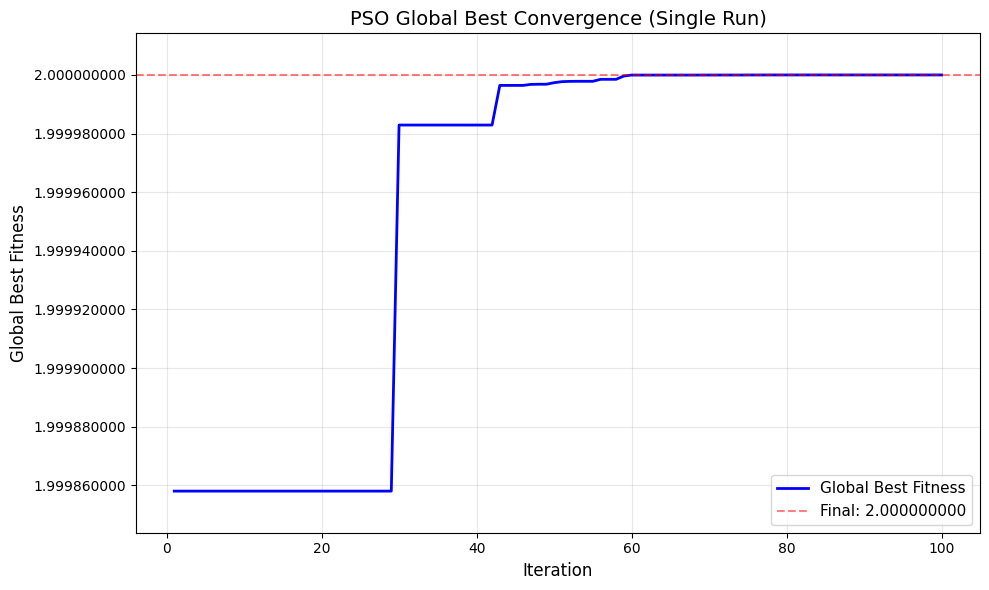

Convergence plot saved to pso_w_max=0.9, w_min=0.4 (default)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_w_max=0.9, w_min=0.1 (aggressive)_convergence.csv


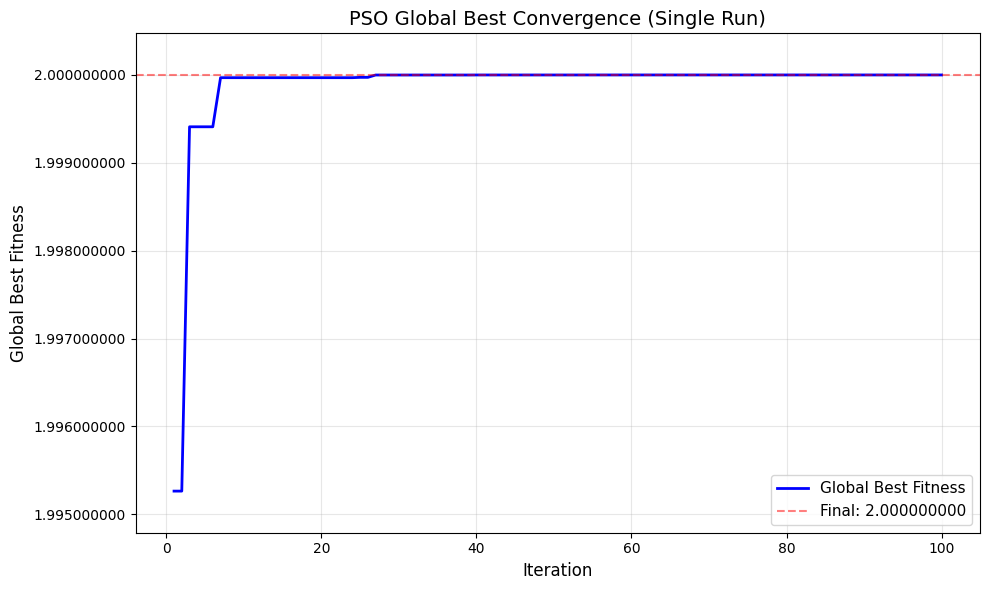

Convergence plot saved to pso_w_max=0.9, w_min=0.1 (aggressive)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_w_max=w_min=0.5 (constant)_convergence.csv


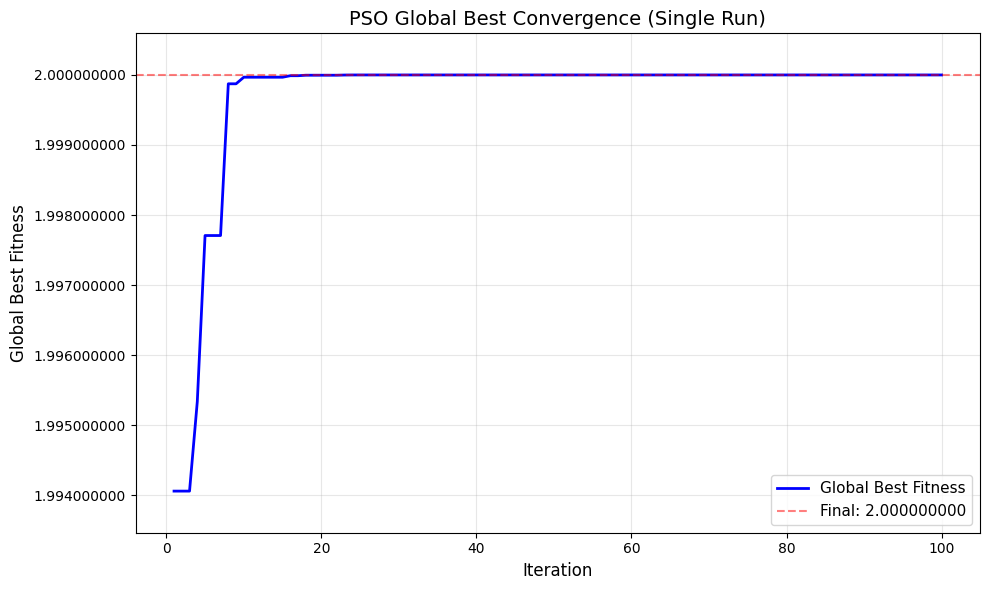

Convergence plot saved to pso_w_max=w_min=0.5 (constant)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_w_max=1.0, w_min=0.0 (full range)_convergence.csv


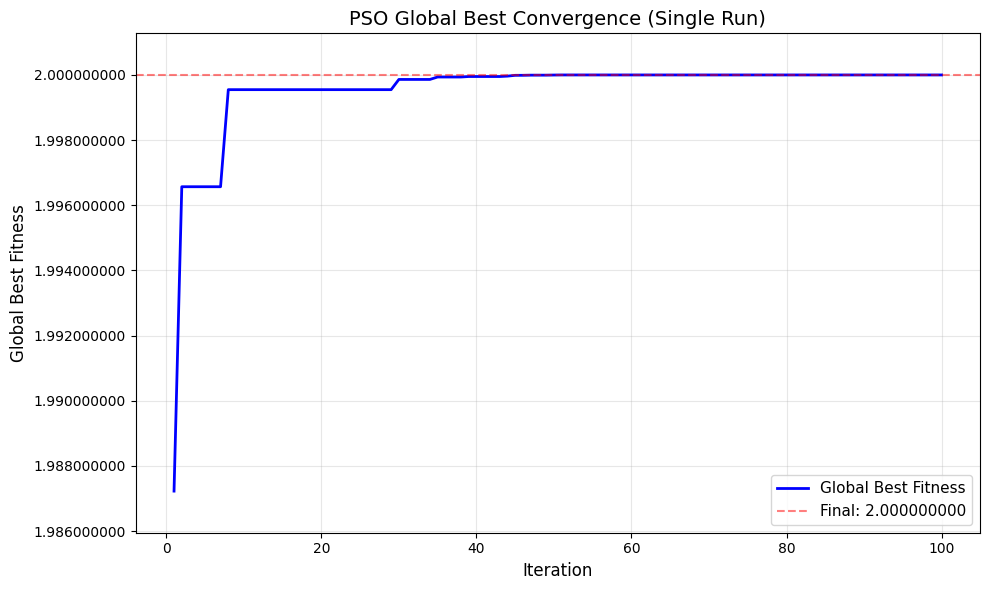

Convergence plot saved to pso_w_max=1.0, w_min=0.0 (full range)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000


In [15]:
print("Parameter Sensitivity single run: Inertia Weight")

w_configs = [
    {"label": "w_max=0.9, w_min=0.4 (default)", "w_max": 0.9, "w_min": 0.4},
    {"label": "w_max=0.9, w_min=0.1 (aggressive)", "w_max": 0.9, "w_min": 0.1},
    {"label": "w_max=w_min=0.5 (constant)", "w_max": 0.5, "w_min": 0.5},
    {"label": "w_max=1.0, w_min=0.0 (full range)", "w_max": 1.0, "w_min": 0.0},
]
w1_results = {}
for cfg in w_configs:

    swarm = Swarm(num_particles=SWARM_SIZE, fitness_func=fitness, 
              w_max=cfg["w_max"], w_min=cfg["w_min"], c1=2.0, c2=2.0, m_v=[0.5, 0.5])

    #get results of best position, best fitness, and history
    best_pos, best_fit, history = swarm.simulate(max_iter=100)

    w1_results[cfg["label"]] = {"histories": history}

    #plot convergence
    plot_convergence(history, filename=f'pso_{cfg["label"]}_convergence.png', 
                    title='PSO Global Best Convergence (Single Run)', csv_filename=f'pso_{cfg["label"]}_convergence.csv')

    print(f"\nFinal Best Position: x={best_pos[0]:.4f}, y={best_pos[1]:.4f}")
    print(f"Final Best Fitness: {best_fit:.6f}")

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, data in w1_results.items():
    history = data["histories"]  # this is just a single list
    ax.plot(range(len(history)), history, linewidth=2, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel('Best-so-far Fitness')
ax.set_title('Sensitivity: Inertia Weight Single Run')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sensitivity_inertia_single_run.png', dpi=150)
plt.close()

Parameter Sensitivity single run: Acceleration Constants
Convergence data saved to pso_c1=2.0, c2=2.0 (default)_convergence.csv


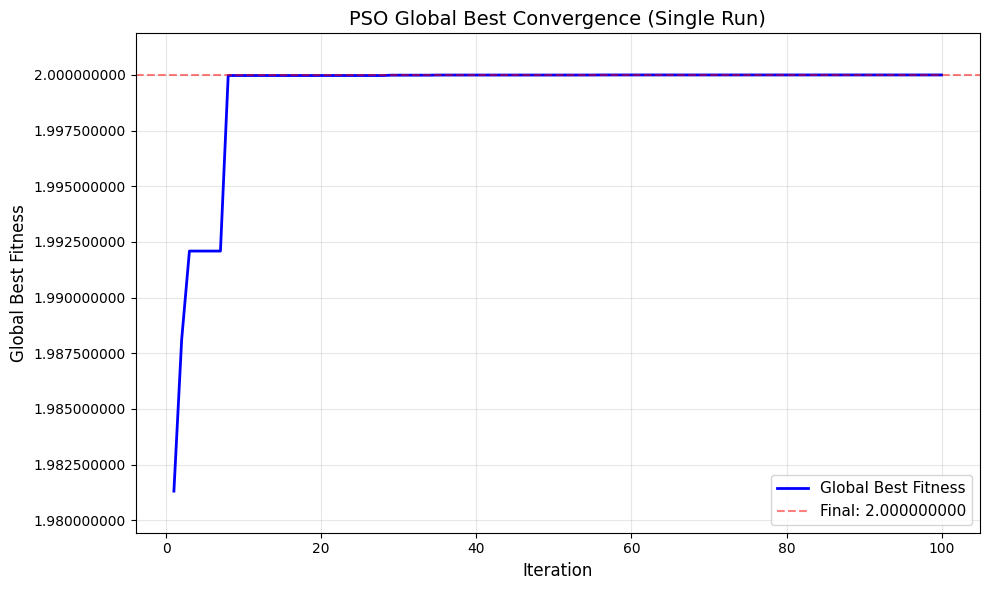

Convergence plot saved to pso_c1=2.0, c2=2.0 (default)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_c1=1.0, c2=3.0 (social)_convergence.csv


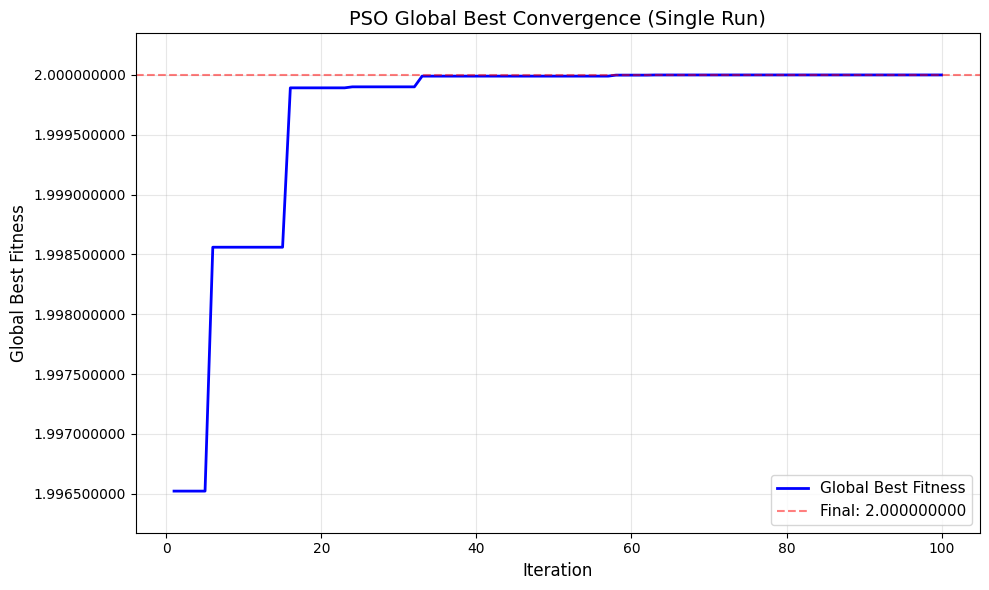

Convergence plot saved to pso_c1=1.0, c2=3.0 (social)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_c1=3.0, c2=1.0 (cognitive)_convergence.csv


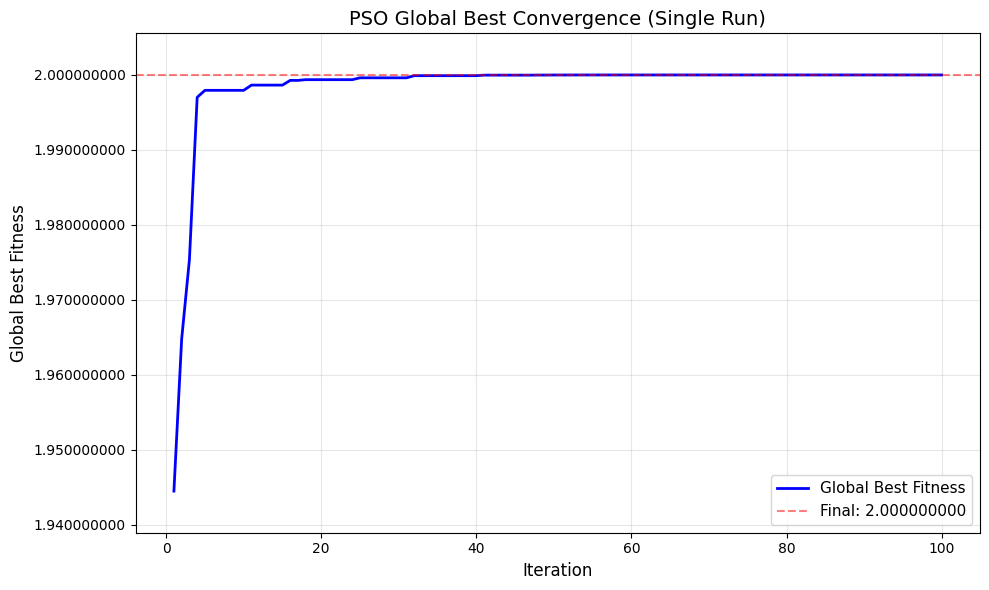

Convergence plot saved to pso_c1=3.0, c2=1.0 (cognitive)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_c1=1.5, c2=1.5 (balanced)_convergence.csv


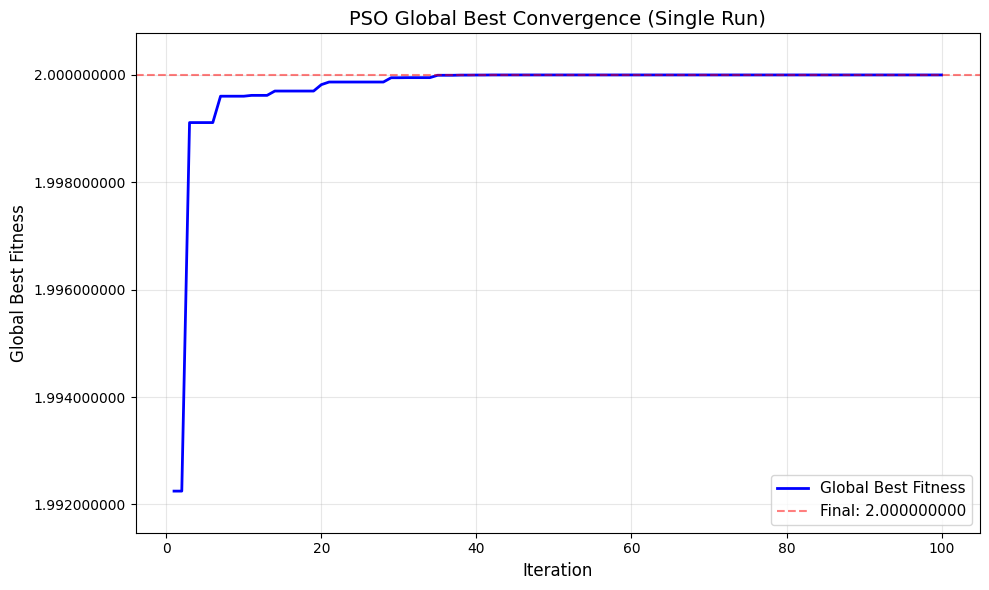

Convergence plot saved to pso_c1=1.5, c2=1.5 (balanced)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000


In [17]:
print("Parameter Sensitivity single run: Acceleration Constants")

c_configs = [
    {"label": "c1=2.0, c2=2.0 (default)", "c1": 2.0, "c2": 2.0},
    {"label": "c1=1.0, c2=3.0 (social)", "c1": 1.0, "c2": 3.0},
    {"label": "c1=3.0, c2=1.0 (cognitive)", "c1": 3.0, "c2": 1.0},
    {"label": "c1=1.5, c2=1.5 (balanced)", "c1": 1.5, "c2": 1.5},
]
c1_results = {}
for cfg in c_configs:
    swarm = Swarm(num_particles=SWARM_SIZE, fitness_func=fitness, 
              w_max=0.9, w_min=0.4, c1=cfg["c1"], c2=cfg["c2"], m_v=[0.5, 0.5])

    #get results of best position, best fitness, and history
    best_pos, best_fit, history = swarm.simulate(max_iter=100)

    c1_results[cfg["label"]] = {"histories": history}

    #plot convergence
    plot_convergence(history, filename=f'pso_{cfg["label"]}_convergence.png', 
                    title='PSO Global Best Convergence (Single Run)', csv_filename=f'pso_{cfg["label"]}_convergence.csv')

    print(f"\nFinal Best Position: x={best_pos[0]:.4f}, y={best_pos[1]:.4f}")
    print(f"Final Best Fitness: {best_fit:.6f}")


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, data in c1_results.items():
    history = data["histories"]  # this is just a single list
    ax.plot(range(len(history)), history, linewidth=2, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel('Best-so-far Fitness')
ax.set_title('Sensitivity single run: Acceleration Constants')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sensitivity_acceleration_single_run.png', dpi=150)
plt.close()

Parameter Sensitivity single run: Velocity Limit (m_v)
Convergence data saved to pso_m_v=0.1 (conservative)_convergence.csv


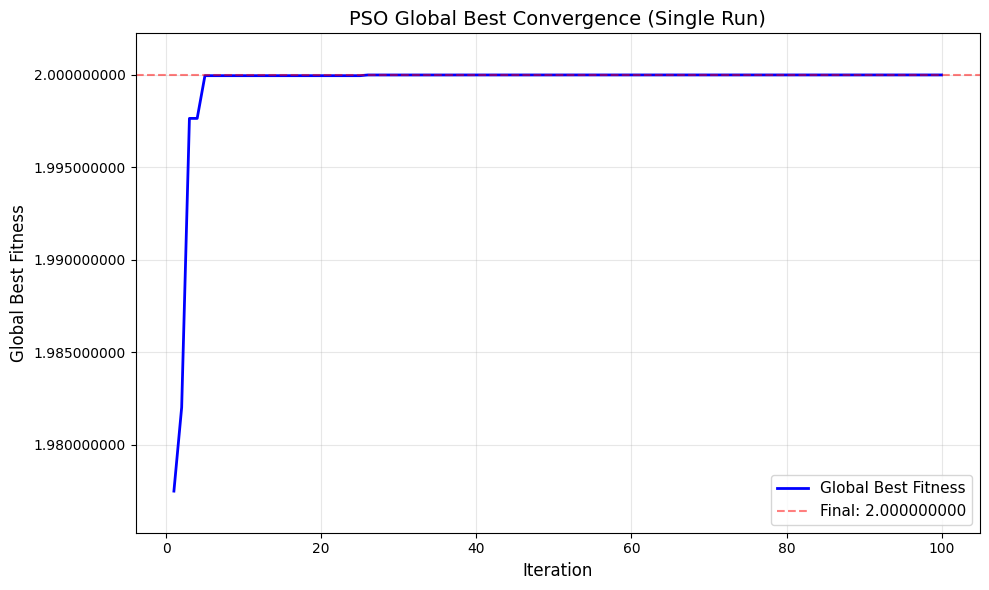

Convergence plot saved to pso_m_v=0.1 (conservative)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_m_v=0.5 (default)_convergence.csv


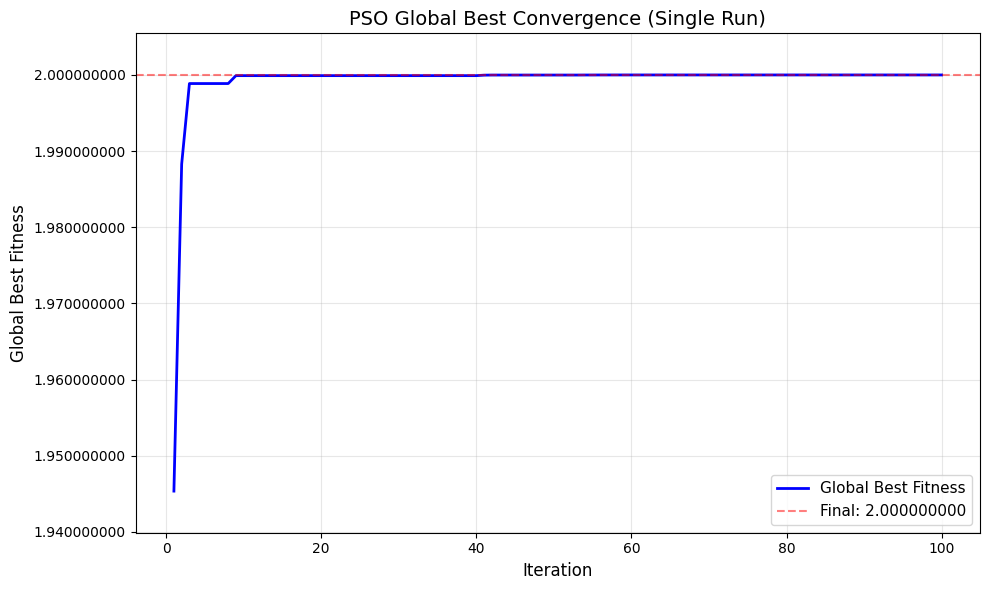

Convergence plot saved to pso_m_v=0.5 (default)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_m_v=0.8 (aggressive)_convergence.csv


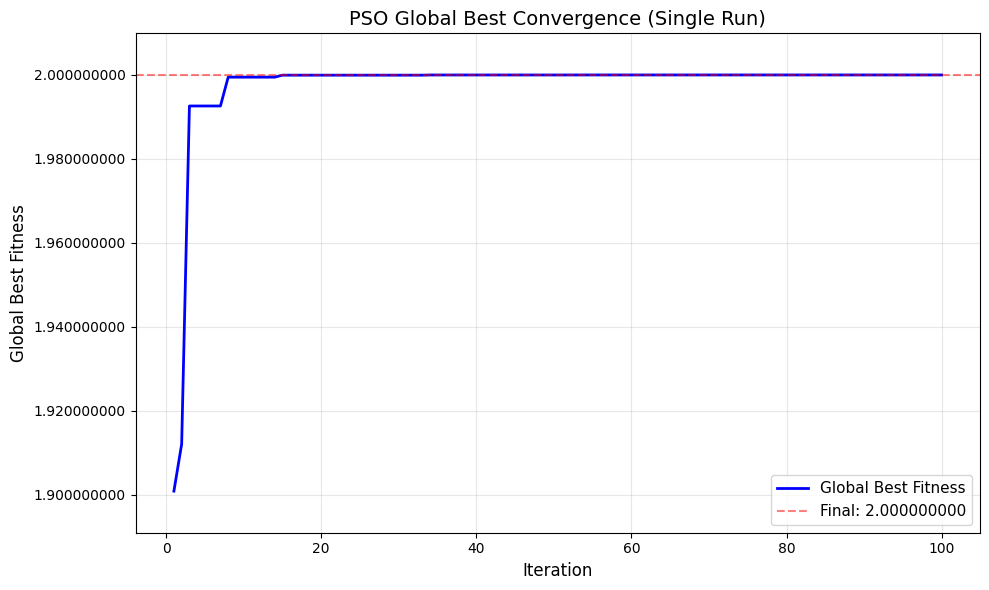

Convergence plot saved to pso_m_v=0.8 (aggressive)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000
Convergence data saved to pso_m_v=1.0 (maximum)_convergence.csv


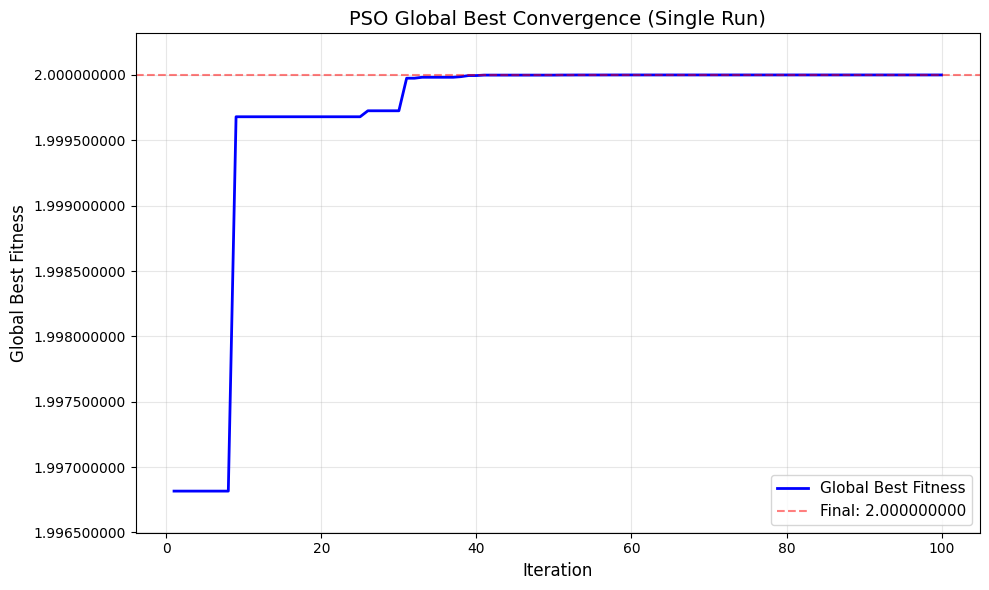

Convergence plot saved to pso_m_v=1.0 (maximum)_convergence.png

Final Best Position: x=1.0000, y=2.0000
Final Best Fitness: 2.000000


In [19]:
print("Parameter Sensitivity single run: Velocity Limit (m_v)")

v_configs = [
    {"label": "m_v=0.1 (conservative)", "m_v": [0.1, 0.1]},
    {"label": "m_v=0.5 (default)", "m_v": [0.5, 0.5]},
    {"label": "m_v=0.8 (aggressive)", "m_v": [0.8, 0.8]},
    {"label": "m_v=1.0 (maximum)", "m_v": [1.0, 1.0]},
]
v1_results = {}
for cfg in v_configs:
    swarm = Swarm(num_particles=SWARM_SIZE, fitness_func=fitness, 
            w_max=0.9, w_min=0.4, c1=2.0, c2=2.0, m_v=cfg["m_v"])

    #get results of best position, best fitness, and history
    best_pos, best_fit, history = swarm.simulate(max_iter=100)

    v1_results[cfg["label"]] = {"histories": history}

    #plot convergence
    plot_convergence(history, filename=f'pso_{cfg["label"]}_convergence.png', 
                    title='PSO Global Best Convergence (Single Run)', csv_filename=f'pso_{cfg["label"]}_convergence.csv')

    print(f"\nFinal Best Position: x={best_pos[0]:.4f}, y={best_pos[1]:.4f}")
    print(f"Final Best Fitness: {best_fit:.6f}")

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, data in v1_results.items():
    history = data["histories"]  # this is just a single list
    ax.plot(range(len(history)), history, linewidth=2, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel('Best-so-far Fitness')
ax.set_title('Parameter Sensitivity single run: Velocity Limit (m_v)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sensitivity_velocity_limit_run.png', dpi=150)
plt.close()

# Parameter 30 runs

In [21]:
print("Parameter Sensitivity: Inertia Weight")

w_configs = [
    {"label": "w_max=0.9, w_min=0.4 (default)", "w_max": 0.9, "w_min": 0.4},
    {"label": "w_max=0.9, w_min=0.1 (aggressive)", "w_max": 0.9, "w_min": 0.1},
    {"label": "w_max=w_min=0.5 (constant)", "w_max": 0.5, "w_min": 0.5},
    {"label": "w_max=1.0, w_min=0.0 (full range)", "w_max": 1.0, "w_min": 0.0},
]
w_results = {}
for cfg in w_configs:
    f_list, h_list, _ = run_multiple(
        'pso', num_runs=NUM_RUNS, max_iter=MAX_ITER,
        num_particles=SWARM_SIZE, w_max=cfg["w_max"], w_min=cfg["w_min"],
        c1=2.0, c2=2.0, m_v=[0.5, 0.5]
    )
    w_results[cfg["label"]] = {"fitness": f_list, "histories": h_list}
    print(f"  {cfg['label']}: mean={np.mean(f_list):.6f} +/- {np.std(f_list):.6f}")


Parameter Sensitivity: Inertia Weight
  w_max=0.9, w_min=0.4 (default): mean=2.000000 +/- 0.000000
  w_max=0.9, w_min=0.1 (aggressive): mean=2.000000 +/- 0.000000
  w_max=w_min=0.5 (constant): mean=2.000000 +/- 0.000000
  w_max=1.0, w_min=0.0 (full range): mean=2.000000 +/- 0.000000


In [22]:
print("Parameter Sensitivity: Acceleration Constants")

c_configs = [
    {"label": "c1=2.0, c2=2.0 (default)", "c1": 2.0, "c2": 2.0},
    {"label": "c1=1.0, c2=3.0 (social)", "c1": 1.0, "c2": 3.0},
    {"label": "c1=3.0, c2=1.0 (cognitive)", "c1": 3.0, "c2": 1.0},
    {"label": "c1=1.5, c2=1.5 (balanced)", "c1": 1.5, "c2": 1.5},
]
c_results = {}
for cfg in c_configs:
    f_list, h_list, _ = run_multiple(
        'pso', num_runs=NUM_RUNS, max_iter=MAX_ITER,
        num_particles=SWARM_SIZE, w_max=0.9, w_min=0.4,
        c1=cfg["c1"], c2=cfg["c2"], m_v=[0.5, 0.5]
    )
    c_results[cfg["label"]] = {"fitness": f_list, "histories": h_list}
    print(f"  {cfg['label']}: mean={np.mean(f_list):.6f} +/- {np.std(f_list):.6f}")


Parameter Sensitivity: Acceleration Constants
  c1=2.0, c2=2.0 (default): mean=2.000000 +/- 0.000000
  c1=1.0, c2=3.0 (social): mean=2.000000 +/- 0.000000
  c1=3.0, c2=1.0 (cognitive): mean=2.000000 +/- 0.000000
  c1=1.5, c2=1.5 (balanced): mean=2.000000 +/- 0.000000


In [23]:
print("Parameter Sensitivity: Velocity Limit (m_v)")

v_configs = [
    {"label": "m_v=0.1 (conservative)", "m_v": [0.1, 0.1]},
    {"label": "m_v=0.5 (default)", "m_v": [0.5, 0.5]},
    {"label": "m_v=0.8 (aggressive)", "m_v": [0.8, 0.8]},
    {"label": "m_v=1.0 (maximum)", "m_v": [1.0, 1.0]},
]
v_results = {}
for cfg in v_configs:
    f_list, h_list, _ = run_multiple(
        'pso', num_runs=NUM_RUNS, max_iter=MAX_ITER,
        num_particles=SWARM_SIZE, w_max=0.9, w_min=0.4,
        c1=2.0, c2=2.0, m_v=cfg["m_v"]
    )
    v_results[cfg["label"]] = {"fitness": f_list, "histories": h_list}
    print(f"  {cfg['label']}: mean={np.mean(f_list):.6f} +/- {np.std(f_list):.6f}")

Parameter Sensitivity: Velocity Limit (m_v)
  m_v=0.1 (conservative): mean=2.000000 +/- 0.000000
  m_v=0.5 (default): mean=2.000000 +/- 0.000000
  m_v=0.8 (aggressive): mean=2.000000 +/- 0.000000
  m_v=1.0 (maximum): mean=2.000000 +/- 0.000000


# t-test

In [24]:
print("Statistical Comparison: PSO vs GA")

#one-tailed t-test
t_onetail_stat, p_onetail_value = stats.ttest_ind(pso_fitness, ga_fitness, alternative='greater')
print(f"t-test: t={t_onetail_stat:.4f}, p={p_onetail_value:.6f}")
alpha = 0.05
if p_onetail_value < alpha:
    print("Reject the null hypothesis: the mean of x is greater than the mean of y")
else:
    print("Fail to reject the null hypothesis: the mean of x is not greater than the mean of y")

Statistical Comparison: PSO vs GA
t-test: t=3.7914, p=0.000180
Reject the null hypothesis: the mean of x is greater than the mean of y


In [25]:
#two-tailed t-test
t_twotail_stat, p_twotail_value = stats.ttest_ind(pso_fitness, ga_fitness)
print(f"t-test: t={t_twotail_stat:.4f}, p={p_twotail_value:.6f}")
alpha = 0.05
if p_twotail_value < alpha:
    print("Reject the null hypothesis: the means of x and y are different")
else:
    print("Fail to reject the null hypothesis: the means of x and y are not different")

t-test: t=3.7914, p=0.000359
Reject the null hypothesis: the means of x and y are different


In [26]:
print("\nGenerating plots")
iters = range(1, MAX_ITER + 1)


Generating plots


# Generating plots

In [27]:
# Plot 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(iters, np.mean(pso_histories, axis=0), 'b-', linewidth=2, label='PSO (mean)')
ax.plot(iters, np.mean(ga_histories, axis=0), 'r--', linewidth=2, label='GA (mean)')
ax.set_xlabel('Iteration / Generation'); ax.set_ylabel('Best-so-far Fitness')
ax.set_title('Convergence Comparison: PSO vs GA (30 runs)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('convergence_pso_vs_ga.png', dpi=150); plt.close()


In [28]:
# Plot 2
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([pso_fitness, ga_fitness], labels=['PSO', 'GA'])
ax.set_ylabel('Final Best Fitness'); ax.set_title('Distribution of Final Best Fitness (30 runs)')
ax.grid(True, alpha=0.3, axis='y'); plt.tight_layout(); plt.savefig('boxplot_comparison.png', dpi=150); plt.close()

/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_69698/2955710997.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([pso_fitness, ga_fitness], labels=['PSO', 'GA'])


In [29]:
# Plot 3
fig, ax = plt.subplots(figsize=(10, 6))
for label, data in w_results.items(): ax.plot(iters, np.mean(data["histories"], axis=0), linewidth=2, label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('Best-so-far Fitness'); ax.set_title('Sensitivity: Inertia Weight')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('sensitivity_inertia.png', dpi=150); plt.close()

In [30]:
# Plot 4
fig, ax = plt.subplots(figsize=(10, 6))
for label, data in c_results.items(): ax.plot(iters, np.mean(data["histories"], axis=0), linewidth=2, label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('Best-so-far Fitness'); ax.set_title('Sensitivity: Acceleration Constants')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('sensitivity_acceleration.png', dpi=150); plt.close()


In [31]:
# Plot 5
fig, ax = plt.subplots(figsize=(10, 6))
for label, data in v_results.items(): ax.plot(iters, np.mean(data["histories"], axis=0), linewidth=2, label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('Best-so-far Fitness'); ax.set_title('Sensitivity: Velocity Limit (m_v)')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('sensitivity_velocity.png', dpi=150); plt.close()

In [32]:
# CSVs
with open('pso_results.csv', 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['run', 'best_fitness', 'best_x', 'best_y'])
    for i in range(NUM_RUNS): w.writerow([i+1, pso_fitness[i], pso_positions[i][0], pso_positions[i][1]])

with open('ga_results.csv', 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['run', 'best_fitness', 'best_x', 'best_y'])
    for i in range(NUM_RUNS): w.writerow([i+1, ga_fitness[i], ga_positions[i][0], ga_positions[i][1]])

with open('convergence_history.csv', 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['iteration', 'pso_mean', 'pso_std', 'ga_mean', 'ga_std'])
    for i in range(MAX_ITER):
        pv, gv = [h[i] for h in pso_histories], [h[i] for h in ga_histories]
        w.writerow([i+1, np.mean(pv), np.std(pv), np.mean(gv), np.std(gv)])


In [33]:
print("SUMMARY FOR REPORT\n")

print(f"PSO (30 runs):\n  Mean: {np.mean(pso_fitness):.6f}\n  Std:  {np.std(pso_fitness):.6f}\n  Best: {np.max(pso_fitness):.6f}")
print(f"  Best pos: x={pso_positions[np.argmax(pso_fitness)][0]:.6f}, y={pso_positions[np.argmax(pso_fitness)][1]:.6f}")
print(f"\nGA (30 runs):\n  Mean: {np.mean(ga_fitness):.6f}\n  Std:  {np.std(ga_fitness):.6f}\n  Best: {np.max(ga_fitness):.6f}")
print(f"  Best pos: x={ga_positions[np.argmax(ga_fitness)][0]:.6f}, y={ga_positions[np.argmax(ga_fitness)][1]:.6f}")

print(f"\nStatistical Tests for one-tail:\n  t-test: p={p_onetail_value:.6f}\n")
alpha = 0.05
if p_onetail_value < alpha:
    print("Reject the null hypothesis: the mean of x is greater than the mean of y")
else:
    print("Fail to reject the null hypothesis: the mean of x is not greater than the mean of y")

print(f"\nStatistical Tests for two-tail-tail:\n  t-test: p={p_twotail_value:.6f}\n")
if p_twotail_value < alpha:
    print("Reject the null hypothesis: the means of x and y are different")
else:
    print("Fail to reject the null hypothesis: the means of x and y are not different")


SUMMARY FOR REPORT

PSO (30 runs):
  Mean: 2.000000
  Std:  0.000000
  Best: 2.000000
  Best pos: x=1.000000, y=2.000000

GA (30 runs):
  Mean: 1.999858
  Std:  0.000201
  Best: 1.999993
  Best pos: x=0.998657, y=2.002198

Statistical Tests for one-tail:
  t-test: p=0.000180

Reject the null hypothesis: the mean of x is greater than the mean of y

Statistical Tests for two-tail-tail:
  t-test: p=0.000359

Reject the null hypothesis: the means of x and y are different
